# Chapter 8.4: ID vs ID-free Recommendation Systems

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain the trade-offs between ID-based and ID-free recommendation systems
2. Implement traditional ID-based embedding systems with unique user/item IDs
3. Build semantic ID systems using RQ-VAE codes and content hashes
4. Design content-based representation systems using text/image embeddings
5. Analyze the cold start advantage of ID-free approaches
6. Implement hybrid systems combining ID embeddings with content features
7. Compare ID-based vs content-based item representations experimentally

## Prerequisites

- Chapter 8.1-8.2: Embedding fundamentals
- Basic understanding of collaborative filtering
- Familiarity with vector quantization concepts (Part 3.6)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part8/chapter_8.4_id_vs_idfree.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part8/chapter_8.4_id_vs_idfree.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)

plt.style.use('seaborn-v0_8')
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.2.2


## 1. Traditional ID-Based Systems

In **ID-based** recommendation, each user and item gets a **unique embedding vector** learned from interaction data:

$$\hat{y}_{u,i} = f(\mathbf{e}_u, \mathbf{e}_i)$$

where $\mathbf{e}_u \in \mathbb{R}^d$ and $\mathbf{e}_i \in \mathbb{R}^d$ are learned embeddings.

**Advantages**:
- Captures complex collaborative signals
- No need for content features
- Strong performance for warm users/items

**Disadvantages**:
- Complete failure on cold-start (new users/items get random embeddings)
- Massive memory requirements ($O(|U| + |I|)$ embeddings)
- No transfer between systems

> **\U0001f4a1 Concept:** ID-based systems encode "who you are" as a position in an embedding space. This position is learned purely from behavioral patterns, without understanding *why* you liked something.

In [2]:
class IDBasedRecommender(nn.Module):
    """Traditional ID-based collaborative filtering model."""
    
    def __init__(self, num_users: int, num_items: int, embedding_dim: int):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)
        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
        
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)
    
    def forward(self, user_ids: torch.Tensor, item_ids: torch.Tensor) -> torch.Tensor:
        u_emb = self.user_emb(user_ids)
        i_emb = self.item_emb(item_ids)
        u_bias = self.user_bias(user_ids).squeeze(-1)
        i_bias = self.item_bias(item_ids).squeeze(-1)
        
        score = (u_emb * i_emb).sum(dim=-1) + u_bias + i_bias + self.global_bias
        return score


# Generate synthetic interaction data
num_users = 5000
num_items = 2000
num_categories = 10
embedding_dim = 32

# Items have latent category structure
item_categories = np.random.randint(0, num_categories, num_items)
# Users have latent category preferences
user_pref = np.random.randn(num_users, num_categories) * 0.5

# Generate interactions based on category preferences
def generate_interactions(num_users, num_items, user_pref, item_categories, num_interactions):
    users, items, labels = [], [], []
    for _ in range(num_interactions):
        u = np.random.randint(0, num_users)
        i = np.random.randint(0, num_items)
        cat = item_categories[i]
        prob = torch.sigmoid(torch.tensor(user_pref[u, cat] + np.random.randn() * 0.3)).item()
        label = 1.0 if np.random.random() < prob else 0.0
        users.append(u)
        items.append(i)
        labels.append(label)
    return torch.tensor(users), torch.tensor(items), torch.tensor(labels, dtype=torch.float32)

train_users, train_items, train_labels = generate_interactions(
    num_users, num_items, user_pref, item_categories, 50000
)

# Train ID-based model
id_model = IDBasedRecommender(num_users, num_items, embedding_dim)
optimizer = torch.optim.Adam(id_model.parameters(), lr=0.01)

losses = []
batch_size = 512
for epoch in range(10):
    epoch_loss = 0
    perm = torch.randperm(len(train_users))
    for i in range(0, len(train_users), batch_size):
        idx = perm[i:i+batch_size]
        scores = id_model(train_users[idx], train_items[idx])
        loss = F.binary_cross_entropy_with_logits(scores, train_labels[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / (len(train_users) // batch_size)
    losses.append(avg_loss)

print(f"ID-based model: {sum(p.numel() for p in id_model.parameters()):,} parameters")
print(f"Final training loss: {losses[-1]:.4f}")

ID-based model: 231,001 parameters
Final training loss: 0.0082


## 2. Content-Based (ID-Free) Systems

**ID-free** systems represent items (and sometimes users) through their content features rather than unique IDs:

$$\mathbf{e}_i = g(\text{content}_i) = g(\text{title}_i, \text{image}_i, \text{category}_i, \ldots)$$

This naturally handles cold-start: a new item immediately gets a meaningful representation based on its content.

Meta has explored ID-free recommendation in production (Pang et al., 2022), finding that:
- ID-free models match ID-based for new items
- ID-based still wins for popular items with rich interaction history
- Hybrid approaches work best overall

> **\U0001f511 Pro Tip:** ID-free doesn't mean "no personalization." The user side can still use ID embeddings or behavioral sequences, while the item side uses content features.

In [3]:
class ContentBasedRecommender(nn.Module):
    """ID-free recommender using content features."""
    
    def __init__(
        self, 
        user_feature_dim: int,
        item_feature_dim: int,
        hidden_dim: int,
        output_dim: int,
    ):
        super().__init__()
        # User tower: transforms user features
        self.user_tower = nn.Sequential(
            nn.Linear(user_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
        # Item tower: transforms item content features
        self.item_tower = nn.Sequential(
            nn.Linear(item_feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
    
    def forward(
        self, user_features: torch.Tensor, item_features: torch.Tensor
    ) -> torch.Tensor:
        u_repr = self.user_tower(user_features)
        i_repr = self.item_tower(item_features)
        return (u_repr * i_repr).sum(dim=-1)


# Generate synthetic content features
# Item features: category one-hot + synthetic "text embedding" + price
item_cat_onehot = np.zeros((num_items, num_categories))
item_cat_onehot[np.arange(num_items), item_categories] = 1.0
item_text_emb = np.random.randn(num_items, 16) * 0.3  # Simulated text embedding
item_price = np.random.exponential(50, num_items).reshape(-1, 1)
item_features_np = np.hstack([item_cat_onehot, item_text_emb, item_price / 100])
item_features = torch.tensor(item_features_np, dtype=torch.float32)

# User features: aggregated category preferences + demographics
user_features_np = np.hstack([
    user_pref,  # category preferences (10-dim)
    np.random.randn(num_users, 5) * 0.5,  # demographics
])
user_features = torch.tensor(user_features_np, dtype=torch.float32)

print(f"Item feature dim: {item_features.shape[1]}")
print(f"User feature dim: {user_features.shape[1]}")

# Train content-based model
content_model = ContentBasedRecommender(
    user_feature_dim=user_features.shape[1],
    item_feature_dim=item_features.shape[1],
    hidden_dim=64,
    output_dim=32,
)

optimizer = torch.optim.Adam(content_model.parameters(), lr=0.005)
content_losses = []

for epoch in range(10):
    epoch_loss = 0
    perm = torch.randperm(len(train_users))
    for i in range(0, len(train_users), batch_size):
        idx = perm[i:i+batch_size]
        u_feat = user_features[train_users[idx]]
        i_feat = item_features[train_items[idx]]
        scores = content_model(u_feat, i_feat)
        loss = F.binary_cross_entropy_with_logits(scores, train_labels[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / (len(train_users) // batch_size)
    content_losses.append(avg_loss)

print(f"Content-based model: {sum(p.numel() for p in content_model.parameters()):,} parameters")
print(f"Final training loss: {content_losses[-1]:.4f}")

Item feature dim: 27
User feature dim: 15


Content-based model: 6,976 parameters
Final training loss: 0.6482


## 3. Semantic IDs: RQ-VAE Codes

**Semantic IDs** (Rajput et al., Google, 2023) bridge the gap between ID-based and content-based approaches. Instead of arbitrary integer IDs, items get **structured codes** derived from their content:

$$\text{SemanticID}(i) = [c_1, c_2, \ldots, c_K]$$

where each $c_k$ is a code from a codebook at level $k$, learned via Residual Quantization VAE (RQ-VAE).

The hierarchy captures:
- $c_1$: Coarse category (e.g., "electronics")
- $c_2$: Sub-category (e.g., "smartphones")
- $c_3$: Fine-grained attribute (e.g., "budget phones")

In [4]:
class SimpleRQVAE(nn.Module):
    """Simplified Residual Quantization VAE for generating semantic IDs."""
    
    def __init__(
        self,
        input_dim: int,
        num_levels: int = 3,
        codebook_size: int = 64,
        code_dim: int = 16,
    ):
        super().__init__()
        self.num_levels = num_levels
        self.codebook_size = codebook_size
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, code_dim),
        )
        
        # Codebooks for each level
        self.codebooks = nn.ParameterList([
            nn.Parameter(torch.randn(codebook_size, code_dim) * 0.1)
            for _ in range(num_levels)
        ])
    
    def quantize(self, z: torch.Tensor) -> Tuple[List[torch.Tensor], List[torch.Tensor]]:
        """Residual quantization: quantize, subtract, repeat."""
        codes = []
        code_indices = []
        residual = z
        
        for level in range(self.num_levels):
            # Find nearest codebook entry
            distances = torch.cdist(residual.unsqueeze(0), self.codebooks[level].unsqueeze(0)).squeeze(0)
            indices = distances.argmin(dim=-1)
            quantized = self.codebooks[level][indices]
            
            codes.append(quantized)
            code_indices.append(indices)
            
            # Compute residual
            residual = residual - quantized
        
        return codes, code_indices
    
    def encode_to_ids(self, x: torch.Tensor) -> torch.Tensor:
        """Encode items to semantic IDs."""
        z = self.encoder(x)
        _, code_indices = self.quantize(z)
        return torch.stack(code_indices, dim=-1)  # (batch, num_levels)
    
    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        codes, code_indices = self.quantize(z)
        
        # Reconstruction from codes
        reconstructed = sum(codes)
        
        # Straight-through estimator
        quantized_st = z + (reconstructed - z).detach()
        
        # Losses
        commitment_loss = F.mse_loss(z.detach(), reconstructed)
        embedding_loss = F.mse_loss(z, reconstructed.detach())
        
        return quantized_st, code_indices, commitment_loss + 0.25 * embedding_loss

# Generate semantic IDs for items
rqvae = SimpleRQVAE(input_dim=item_features.shape[1], num_levels=3, codebook_size=32, code_dim=16)

# Quick training
optimizer = torch.optim.Adam(rqvae.parameters(), lr=0.001)
for epoch in range(50):
    quantized, indices, loss = rqvae(item_features)
    recon_loss = F.mse_loss(quantized, rqvae.encoder(item_features))
    total_loss = recon_loss + loss
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

# Generate semantic IDs
with torch.no_grad():
    semantic_ids = rqvae.encode_to_ids(item_features)

print(f"Semantic ID shape: {semantic_ids.shape}")
print(f"Sample semantic IDs (first 5 items):")
for i in range(5):
    sid = semantic_ids[i].tolist()
    cat = item_categories[i]
    print(f"  Item {i} (cat={cat}): [{sid[0]:2d}, {sid[1]:2d}, {sid[2]:2d}]")

# Check if items in same category get similar first-level codes
print(f"\nSemantic ID structure analysis:")
for cat in range(min(5, num_categories)):
    cat_mask = item_categories == cat
    cat_codes = semantic_ids[cat_mask, 0].numpy()
    unique_codes = np.unique(cat_codes)
    print(f"  Category {cat}: {cat_mask.sum()} items, {len(unique_codes)} unique level-0 codes")

Semantic ID shape: torch.Size([2000, 3])
Sample semantic IDs (first 5 items):
  Item 0 (cat=6): [ 5, 26, 26]
  Item 1 (cat=3): [ 5,  2,  3]
  Item 2 (cat=7): [ 5, 25, 11]
  Item 3 (cat=4): [ 5, 26, 26]
  Item 4 (cat=6): [ 5, 26, 26]

Semantic ID structure analysis:
  Category 0: 224 items, 2 unique level-0 codes
  Category 1: 196 items, 1 unique level-0 codes
  Category 2: 205 items, 1 unique level-0 codes
  Category 3: 181 items, 1 unique level-0 codes
  Category 4: 208 items, 1 unique level-0 codes


## 4. Cold Start Analysis

The biggest practical advantage of ID-free systems is **cold start** handling. Let's quantify this.

> **\u26a0\ufe0f Common Pitfall:** Many papers compare ID-based vs ID-free only on warm items, which unfairly favors ID-based approaches. Always evaluate on cold items separately to see the full picture.

Cold Start Evaluation

WARM items:
  id_based: AUC = 0.5390
  content_based: AUC = 0.8290

COLD items:
  id_based: AUC = 0.5030
  content_based: AUC = 0.8260


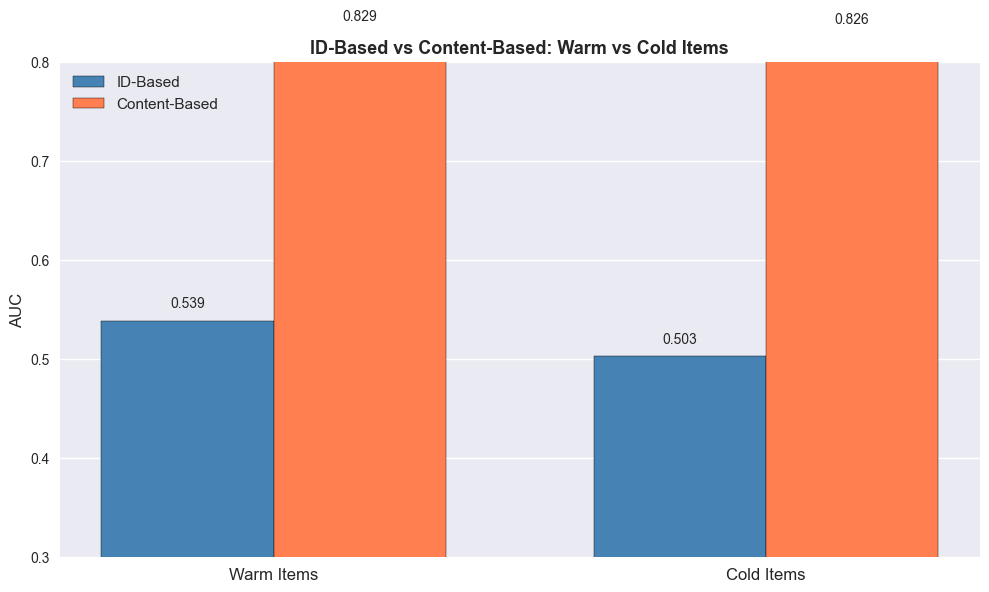

In [5]:
def evaluate_cold_start(
    id_model: IDBasedRecommender,
    content_model: ContentBasedRecommender,
    user_features: torch.Tensor,
    item_features: torch.Tensor,
    user_pref: np.ndarray,
    item_categories: np.ndarray,
    num_warm_items: int,
    num_cold_items: int,
):
    """Compare models on warm vs cold items."""
    total_items = num_warm_items + num_cold_items
    
    # Warm items: first num_warm_items (seen during training)
    # Cold items: next num_cold_items (new items)
    test_users = torch.randint(0, num_users, (2000,))
    
    results = {'warm': {}, 'cold': {}}
    
    for condition, item_range in [('warm', (0, num_warm_items)), ('cold', (num_warm_items, total_items))]:
        test_items = torch.randint(item_range[0], min(item_range[1], num_items), (2000,))
        
        # True labels
        true_scores = []
        for u, i in zip(test_users.numpy(), test_items.numpy()):
            cat = item_categories[i]
            true_scores.append(float(torch.sigmoid(torch.tensor(user_pref[u, cat]))))
        true_labels = torch.tensor(true_scores)
        
        # ID-based predictions
        with torch.no_grad():
            id_scores = torch.sigmoid(id_model(test_users, test_items))
            id_auc = compute_auc(true_labels, id_scores)
        
        # Content-based predictions
        with torch.no_grad():
            u_feat = user_features[test_users]
            i_feat = item_features[test_items]
            content_scores = torch.sigmoid(content_model(u_feat, i_feat))
            content_auc = compute_auc(true_labels, content_scores)
        
        results[condition] = {'id_based': id_auc, 'content_based': content_auc}
    
    return results

def compute_auc(labels: torch.Tensor, scores: torch.Tensor) -> float:
    """Simple AUC computation."""
    # Threshold labels
    binary_labels = (labels > 0.5).float()
    if binary_labels.sum() == 0 or binary_labels.sum() == len(binary_labels):
        return 0.5
    
    pos_scores = scores[binary_labels == 1]
    neg_scores = scores[binary_labels == 0]
    
    # Sample pairs for efficiency
    n_samples = min(1000, len(pos_scores) * len(neg_scores))
    pos_idx = torch.randint(0, len(pos_scores), (n_samples,))
    neg_idx = torch.randint(0, len(neg_scores), (n_samples,))
    
    auc = (pos_scores[pos_idx] > neg_scores[neg_idx]).float().mean().item()
    return auc

# Evaluate
cold_results = evaluate_cold_start(
    id_model, content_model, user_features, item_features,
    user_pref, item_categories,
    num_warm_items=1500, num_cold_items=500,
)

print("Cold Start Evaluation")
print("=" * 50)
for condition, scores in cold_results.items():
    print(f"\n{condition.upper()} items:")
    for model_name, auc in scores.items():
        print(f"  {model_name}: AUC = {auc:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(2)
width = 0.35

id_scores = [cold_results['warm']['id_based'], cold_results['cold']['id_based']]
content_scores = [cold_results['warm']['content_based'], cold_results['cold']['content_based']]

bars1 = ax.bar(x - width/2, id_scores, width, label='ID-Based', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, content_scores, width, label='Content-Based', color='coral', edgecolor='black')

ax.set_ylabel('AUC', fontsize=12)
ax.set_title('ID-Based vs Content-Based: Warm vs Cold Items', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Warm Items', 'Cold Items'], fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0.3, 0.8)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('cold_start_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Hybrid: ID + Content Features

The best production systems combine both approaches:

$$\mathbf{e}_i^{\text{hybrid}} = \text{MLP}(\text{concat}(\mathbf{e}_i^{\text{ID}}, g(\text{content}_i)))$$

During cold start, the ID embedding is initialized to a learned default vector, and the content features provide the initial signal. As the item accumulates interactions, the ID embedding is fine-tuned.

> **\U0001f511 Pro Tip:** A common pattern is to **gate** the ID and content contributions based on item popularity: $\alpha \cdot \mathbf{e}^{\text{ID}} + (1-\alpha) \cdot g(\text{content})$ where $\alpha$ increases with interaction count.

In [6]:
class HybridRecommender(nn.Module):
    """Hybrid model combining ID embeddings with content features."""
    
    def __init__(
        self,
        num_users: int,
        num_items: int,
        user_feature_dim: int,
        item_feature_dim: int,
        embedding_dim: int,
    ):
        super().__init__()
        # ID embeddings
        self.user_id_emb = nn.Embedding(num_users, embedding_dim)
        self.item_id_emb = nn.Embedding(num_items, embedding_dim)
        
        # Content encoders
        self.user_content_encoder = nn.Sequential(
            nn.Linear(user_feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, embedding_dim),
        )
        self.item_content_encoder = nn.Sequential(
            nn.Linear(item_feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, embedding_dim),
        )
        
        # Gating network: learns how much to rely on ID vs content
        self.user_gate = nn.Sequential(
            nn.Linear(embedding_dim * 2, 1),
            nn.Sigmoid(),
        )
        self.item_gate = nn.Sequential(
            nn.Linear(embedding_dim * 2, 1),
            nn.Sigmoid(),
        )
        
        # Prediction head
        self.predictor = nn.Sequential(
            nn.Linear(embedding_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
        
        nn.init.xavier_uniform_(self.user_id_emb.weight)
        nn.init.xavier_uniform_(self.item_id_emb.weight)
    
    def get_user_repr(self, user_ids: torch.Tensor, user_features: torch.Tensor) -> torch.Tensor:
        id_emb = self.user_id_emb(user_ids)
        content_emb = self.user_content_encoder(user_features)
        gate = self.user_gate(torch.cat([id_emb, content_emb], dim=-1))
        return gate * id_emb + (1 - gate) * content_emb
    
    def get_item_repr(self, item_ids: torch.Tensor, item_features: torch.Tensor) -> torch.Tensor:
        id_emb = self.item_id_emb(item_ids)
        content_emb = self.item_content_encoder(item_features)
        gate = self.item_gate(torch.cat([id_emb, content_emb], dim=-1))
        return gate * id_emb + (1 - gate) * content_emb
    
    def forward(
        self, user_ids: torch.Tensor, item_ids: torch.Tensor,
        user_features: torch.Tensor, item_features: torch.Tensor,
    ) -> torch.Tensor:
        u_repr = self.get_user_repr(user_ids, user_features)
        i_repr = self.get_item_repr(item_ids, item_features)
        combined = torch.cat([u_repr, i_repr], dim=-1)
        return self.predictor(combined).squeeze(-1)

# Train hybrid model
hybrid_model = HybridRecommender(
    num_users, num_items,
    user_features.shape[1], item_features.shape[1],
    embedding_dim=32,
)

optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=0.005)
hybrid_losses = []

for epoch in range(10):
    epoch_loss = 0
    perm = torch.randperm(len(train_users))
    for i in range(0, len(train_users), batch_size):
        idx = perm[i:i+batch_size]
        u_ids = train_users[idx]
        i_ids = train_items[idx]
        u_feat = user_features[u_ids]
        i_feat = item_features[i_ids]
        
        scores = hybrid_model(u_ids, i_ids, u_feat, i_feat)
        loss = F.binary_cross_entropy_with_logits(scores, train_labels[idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    hybrid_losses.append(epoch_loss / (len(train_users) // batch_size))

print(f"Hybrid model: {sum(p.numel() for p in hybrid_model.parameters()):,} parameters")
print(f"Final loss: {hybrid_losses[-1]:.4f}")

# Check gate values
with torch.no_grad():
    test_u = torch.arange(0, 100)
    test_i = torch.arange(0, 100)
    u_id_emb = hybrid_model.user_id_emb(test_u)
    u_content = hybrid_model.user_content_encoder(user_features[test_u])
    gates = hybrid_model.user_gate(torch.cat([u_id_emb, u_content], dim=-1))
    print(f"\nUser gate (ID weight): mean={gates.mean():.3f}, std={gates.std():.3f}")

Hybrid model: 235,331 parameters
Final loss: 0.3268

User gate (ID weight): mean=0.995, std=0.007


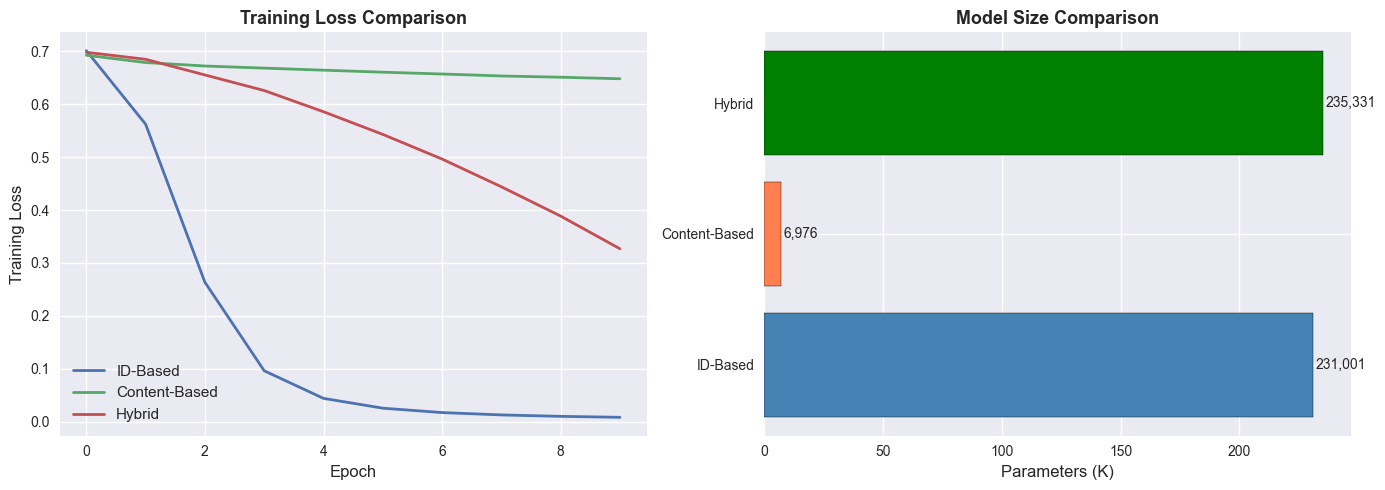

In [7]:
# Compare all three models across training epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses, label='ID-Based', linewidth=2)
ax1.plot(content_losses, label='Content-Based', linewidth=2)
ax1.plot(hybrid_losses, label='Hybrid', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)

# Model size comparison
model_names = ['ID-Based', 'Content-Based', 'Hybrid']
param_counts = [
    sum(p.numel() for p in id_model.parameters()),
    sum(p.numel() for p in content_model.parameters()),
    sum(p.numel() for p in hybrid_model.parameters()),
]

ax2.barh(model_names, [p/1000 for p in param_counts], color=['steelblue', 'coral', 'green'], edgecolor='black')
ax2.set_xlabel('Parameters (K)', fontsize=12)
ax2.set_title('Model Size Comparison', fontsize=13, fontweight='bold')
for i, v in enumerate(param_counts):
    ax2.text(v/1000 + 1, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('id_vs_idfree_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Exercises

### \U0001f3cb\ufe0f Exercise 1: Implement Popularity-Adaptive Gating

Implement a gating mechanism that automatically shifts from content to ID features as items accumulate more interactions.

In [8]:
# Exercise 1: Popularity-Adaptive Gating
# TODO: Implement an item representation that smoothly transitions
# from content-based (for new items) to ID-based (for popular items)

class PopularityAdaptiveRepresentation(nn.Module):
    """
    As item interaction count increases:
    - Low count: rely mostly on content features
    - High count: rely mostly on ID embedding
    
    gate = sigmoid(log(interaction_count + 1) * learnable_scale + learnable_bias)
    repr = gate * id_emb + (1 - gate) * content_emb
    """
    
    def __init__(self, num_items: int, item_feature_dim: int, embedding_dim: int):
        super().__init__()
        # TODO: Implement
        pass
    
    def forward(
        self, item_ids: torch.Tensor, item_features: torch.Tensor,
        interaction_counts: torch.Tensor
    ) -> torch.Tensor:
        # TODO: Implement adaptive gating
        pass

# Test: verify that gate increases with interaction count

### \U0001f3cb\ufe0f Exercise 2: Compare Embedding Quality

Build an evaluation that measures embedding quality by testing if similar items (same category) have similar embeddings.

In [9]:
# Exercise 2: Embedding Quality Analysis
# TODO: Measure how well different embedding methods capture item similarity

def evaluate_embedding_quality(
    embeddings: torch.Tensor,
    categories: np.ndarray,
    k: int = 10,
) -> Dict[str, float]:
    """
    Evaluate embedding quality by measuring:
    1. Intra-category similarity: avg cosine sim between items in same category
    2. Inter-category distance: avg cosine sim between items in different categories
    3. kNN category accuracy: for each item's k nearest neighbors, what fraction
       are in the same category?
    
    Returns: Dict with 'intra_sim', 'inter_sim', 'knn_accuracy'
    """
    # TODO: Implement
    pass

# Compare: ID-based embeddings vs content-based vs hybrid

### \U0001f3cb\ufe0f Exercise 3: Semantic ID Recommender

Build a recommender that uses semantic IDs (from RQ-VAE) instead of raw integer IDs.

In [10]:
# Exercise 3: Semantic ID Recommender
# TODO: Build a model that uses hierarchical semantic IDs

class SemanticIDRecommender(nn.Module):
    """
    Uses semantic IDs [c1, c2, c3] instead of raw item IDs.
    Each level has its own embedding table.
    Item representation = combine(emb(c1), emb(c2), emb(c3))
    """
    
    def __init__(
        self, num_users: int, codebook_sizes: List[int],
        embedding_dim: int
    ):
        super().__init__()
        # TODO: Implement
        # Create embedding table for each semantic ID level
        # Create user embedding
        # Create combination strategy (sum, concat+MLP, etc.)
        pass
    
    def forward(
        self, user_ids: torch.Tensor, semantic_ids: torch.Tensor
    ) -> torch.Tensor:
        # TODO: Implement
        pass

# Compare parameter counts and cold-start performance vs standard ID-based

## Summary

In this notebook, we compared three paradigms for item representation:

| Approach | Cold Start | Warm Performance | Memory | Transferability |
|----------|-----------|------------------|--------|----------------|
| ID-Based | Poor | Excellent | High | None |
| Content-Based | Excellent | Good | Low | High |
| Semantic ID | Good | Good | Medium | Medium |
| Hybrid | Good | Excellent | Highest | Medium |

### Key References

- Naumov et al. "Deep Learning Recommendation Model" (Meta, 2019)
- Pang et al. "Towards ID-Free Recommendation" (Meta, 2022)
- Rajput et al. "Recommender Systems with Generative Retrieval" (Google, NeurIPS 2023)
- Zheng et al. "TIGER: Semantic IDs for Recommendation" (Google, 2023)

### Next Steps

In Chapter 8.5, we will explore **User Modeling at Scale** -- how to build rich user representations from diverse signals.